# Representational Geometry as a Fidelity Metric for Connectome-Constrained Neural Emulations

**Experiment 2: ON + OFF Edges | Michael Zhou | Georgia Tech ECE**

This notebook extends Experiment 1 to test whether the representational geometry finding generalizes across stimulus polarity — using both ON and OFF moving edges as stimuli (24 conditions: 12 directions × 2 polarities). A fidelity signal that holds across polarities would strengthen the claim that representational geometry reflects a general property of connectome structure, not a feature of the ON pathway alone.

**Key question:** Does the direction-sensitive representational geometry observed for ON edges also emerge for OFF edges, and does the combined ON+OFF geometry remain specific to connectome-constrained networks?

**References**
- Lappalainen et al. 2024. Connectome-constrained networks predict neural activity across the fly visual system. *Nature* 634, 1132–1140. https://www.nature.com/articles/s41586-024-07939-3
- Shiu et al. 2024. A Drosophila computational brain model reveals sensorimotor processing. *Nature* 634, 210–219. https://www.nature.com/articles/s41586-024-07763-9
- Kriegeskorte et al. 2008. Representational similarity analysis. *Frontiers in Systems
  Neuroscience* 2:4. https://www.frontiersin.org/journals/systems-neuroscience/articles/10.3389/neuro.06.004.2008/full
- Kriegeskorte & Wei 2021. Neural tuning and representational geometry. *Nature Reviews
  Neuroscience* 22, 703–718. https://www.nature.com/articles/s41583-021-00502-3
- Nili et al. 2014. A toolbox for representational similarity analysis. *PLOS Computational Biology* 10(4): e1003553. https://doi.org/10.1371/journal.pcbi.1003553
- Brunton et al. 2026. The digital sphinx: Can a worm brain control a fly body? *bioRxiv*.
  https://www.biorxiv.org/content/10.64898/2026.03.20.713233v1

## Setup

Install Flyvis and download pretrained models. Select **Runtime → Change runtime type → GPU**
before running. Tested on T4 GPU (14.56 GiB).

In [1]:
# Install packages
!git clone https://github.com/TuragaLab/flyvis.git
%cd /content/flyvis
!pip install -e .[examples]
!flyvis download-pretrained

Cloning into 'flyvis'...
remote: Enumerating objects: 5230, done.
remote: Counting objects: 100% (247/247), done.
remote: Compressing objects: 100% (123/123), done.
remote: Total 5230 (delta 181), reused 155 (delta 122), pack-reused 4983 (from 3)
Receiving objects: 100% (5230/5230), 188.39 MiB | 17.00 MiB/s, done.
Resolving deltas: 100% (2675/2675), done.
/content/flyvis
Obtaining file:///content/flyvis
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 97.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.5/12.5 MB 118.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 9.8 MB/s 

## Experiment
**Stimuli:** 24 moving edge conditions — 12 directions at 30° increments (0° through 330°) × 2 polarities (ON and OFF edges)

**Networks:**
- *Connectome-constrained (CC):* All 50 models in the pretrained Flyvis ensemble (indices `000–049` within `flow/0000`, pre-sorted by task error in directory naming), trained to perform optic flow estimation on naturalistic video with connectome-fixed architecture (734 free parameters)
- *Random baseline:* Same 50 model architectures with sign-preserving weight shuffles. Two strategies are used: (1) full Shiu-style shuffling of all 734 free parameters for the n=10 run, mirroring the Experiment 1 primary fidelity run; and (2) shuffling of only the 604 unitary synapse scaling factors (`edges_syn_strength`) while preserving trained time constants and resting potentials for the n=50 run — per Lappalainen et al. (2024) Methods, time constants are clamped during training to prevent instability.

**Population vectors:** Peak central-cell voltage per cell type (65-dim) in response to each stimulus condition

**Reproducibility:** seed=42 (`numpy`, `torch`, `torch.cuda`); `torch.use_deterministic_algorithms(True)`

**Metrics:**
- Cosine distance RDM — scale-invariant, captures pattern geometry across all 24 conditions
- Euclidean distance RDM — captures magnitude differences
- Spearman RDM correlation — measures similarity between CC and random geometry
- Kendall's τ_A RDM correlation — preferred for RDM data with ties (Nili et al. 2014); reported alongside Spearman for all CC vs random comparisons
- Within-ensemble consistency — measures stability of CC representational geometry across trained solutions
- Polarity generalization — whether direction-sensitive geometry observed for ON edges in Experiment 1 extends to OFF edges and the combined ON+OFF space

In [2]:
"""
Experiment 2: Representational Geometry as a Fidelity Metric
for Connectome-Constrained Neural Emulations — ON + OFF Edges

This script extends Experiment 1 (ON edges only) to test whether connectome-constrained
networks (Lappalainen et al. 2024) produce geometrically distinct population codes
compared to randomly initialized networks when stimulated with both ON and OFF moving
edges. A meaningful fidelity signal across both polarities would strengthen the claim
that representational geometry is a general property of the connectome constraint,
not specific to the ON pathway.

Experiment:
- Stimuli: 24 moving edge conditions (12 directions × 2 polarities: ON and OFF)
- Networks: pretrained connectome-constrained ensemble (all 50) vs random baseline
- Population vectors: peak central-cell response per cell type (65-dim)
- Metrics: Euclidean distance, cosine distance, RSA (RDM correlation)

Canonical runs:
    # Primary fidelity result (n=10, full Shiu-style shuffle)
    results = run_experiment(n_models=10, randomization_strategy="full_shiu")

    # Instability documentation (n=50, synapse-only shuffle)
    results = run_experiment(n_models=50, randomization_strategy="synapse_only")

Run on Google Colab with GPU runtime after installing flyvis:
    !git clone https://github.com/TuragaLab/flyvis.git
    %cd /content/flyvis
    !pip install -e .[examples]
    !flyvis download-pretrained
"""

import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.spatial.distance import cosine, euclidean
from scipy.stats import spearmanr, kendalltau

# ── 1. IMPORTS ────────────────────────────────────────────────────────────────

import flyvis
from flyvis import results_dir, EnsembleView
from flyvis.network import NetworkView
from flyvis.datasets.moving_bar import MovingEdge
from flyvis.utils.activity_utils import LayerActivity

# ── REPRODUCIBILITY ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.use_deterministic_algorithms(True)

# ── 2. STIMULUS DATASET ───────────────────────────────────────────────────────

ANGLES = [0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330]  # 12 directions (30° increments)
INTENSITIES = [0, 1]                                                # ON (1) and OFF (0) edges

dataset = MovingEdge(
    offsets=[-10, 11],
    intensities=INTENSITIES,         # include both ON and OFF
    speeds=[19],
    height=80,
    post_pad_mode="continue",
    t_pre=1.0,
    t_post=1.0,
    dt=1 / 200,
    angles=ANGLES,
)

print(f"Dataset: {len(dataset)} samples")
print(dataset.arg_df)


# ── 3. HELPER: EXTRACT POPULATION VECTOR ─────────────────────────────────────

def get_population_vector(network_view, stimulus, dt, use_fade_in=True):
    """
    Simulate network response to a single stimulus and return
    peak central-cell voltage per cell type as a population vector.

    Args:
        network_view: flyvis NetworkView instance
        stimulus: tensor of shape (n_frames, 1, 721)
        dt: temporal resolution
        use_fade_in: whether to use fade_in_state initialization

    Returns:
        pop_vec: numpy array of shape (n_cell_types,)
        cell_types: list of cell type names
    """
    network = network_view.init_network()

    # Ensure shape is (n_frames, 1, 721) — MovingEdge returns (n_frames, 721)
    if stimulus.dim() == 2:
        stimulus = stimulus.unsqueeze(1)  # (n_frames, 721) -> (n_frames, 1, 721)

    if use_fade_in:
        initial_state = network.fade_in_state(1.0, dt, stimulus[[0]])
    else:
        initial_state = None

    with torch.no_grad():
        responses = network.simulate(
            stimulus[None], dt, initial_state=initial_state
        ).cpu()

    layer_act = LayerActivity(responses, network.connectome, keepref=True)

    # Use connectome to enumerate cell types — more reliable than central.keys()
    cell_types = [
        ct.decode() if isinstance(ct, bytes) else ct
        for ct in network.connectome.unique_cell_types[:]
    ]
    pop_vec = np.array([
        layer_act.central[ct].squeeze().numpy().max()
        for ct in cell_types
    ])

    # Free GPU memory after each model to avoid OOM on T4 (14.56 GiB)
    del network, responses, layer_act
    torch.cuda.empty_cache()

    return pop_vec, cell_types


# ── 4. HELPER: BUILD RDM ──────────────────────────────────────────────────────

def build_rdm(pop_matrix, metric="cosine"):
    """
    Build a representational dissimilarity matrix from a population matrix.

    Args:
        pop_matrix: numpy array of shape (n_stimuli, n_cells)
        metric: "cosine" or "euclidean"

    Returns:
        rdm: numpy array of shape (n_stimuli, n_stimuli)
    """
    # Replace any inf/nan with large finite value before computing distances.
    # Random baseline networks with unstable dynamics may produce exploding
    # activations; clamping preserves the comparison (an exploding network is
    # maximally different from a well-behaved biological one) while avoiding
    # downstream crashes.
    pop_matrix = np.nan_to_num(pop_matrix, nan=0.0, posinf=1e3, neginf=-1e3)

    n = pop_matrix.shape[0]
    rdm = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i != j:
                if metric == "cosine":
                    rdm[i, j] = cosine(pop_matrix[i], pop_matrix[j])
                else:
                    rdm[i, j] = euclidean(pop_matrix[i], pop_matrix[j])
    return rdm


# ── 5. HELPER: COMPARE RDMs ──────────────────────────────────────────────────

def rdm_similarity(rdm1, rdm2):
    """
    Compute Spearman rank correlation and Kendall's tau_A between upper
    triangles of two RDMs. Kendall's tau_A is preferred for RDM data with
    ties (Nili et al. 2014); Spearman retained for comparison.
    """
    n = rdm1.shape[0]
    idx = np.triu_indices(n, k=1)
    r_s, p_s = spearmanr(rdm1[idx], rdm2[idx])
    r_k, p_k = kendalltau(rdm1[idx], rdm2[idx])
    return r_s, p_s, r_k, p_k


# ── 5b. HELPER: PERMUTATION TEST ─────────────────────────────────────────────

def permutation_test_rdm(rdm1, rdm2, n_permutations=10000, seed=42):
    """
    Stimulus-label randomization test for RDM correlation (Nili et al. 2014).

    Permutes rows and columns of rdm2 simultaneously to preserve RDM symmetry,
    building a null distribution of RDM correlations under the hypothesis that
    the two RDMs are unrelated. The one-sided p-value is the proportion of
    permuted correlations >= the observed correlation.

    This is the recommended fixed-effects inference procedure from Nili et al.
    (2014) when a single RDM estimate is available (rather than multiple subjects).

    Args:
        rdm1: numpy array of shape (n_stimuli, n_stimuli) — reference RDM
        rdm2: numpy array of shape (n_stimuli, n_stimuli) — candidate RDM
              (stimulus labels of this RDM are permuted)
        n_permutations: number of permutations (default: 10000)
        seed: random seed for reproducibility

    Returns:
        obs_r:    observed Spearman correlation
        p_r:      permutation p-value for Spearman
        obs_tau:  observed Kendall tau_A
        p_tau:    permutation p-value for Kendall tau_A
        null_r:   null distribution of Spearman correlations
        null_tau: null distribution of Kendall tau_A values
    """
    rng = np.random.default_rng(seed)
    n = rdm1.shape[0]
    idx = np.triu_indices(n, k=1)

    # Observed correlations
    obs_r,   _ = spearmanr(rdm1[idx], rdm2[idx])
    obs_tau, _ = kendalltau(rdm1[idx], rdm2[idx])

    # Null distribution via stimulus-label permutation
    null_r   = np.zeros(n_permutations)
    null_tau = np.zeros(n_permutations)

    for i in range(n_permutations):
        perm = rng.permutation(n)
        rdm2_perm = rdm2[np.ix_(perm, perm)]
        null_r[i],   _ = spearmanr(rdm1[idx], rdm2_perm[idx])
        null_tau[i], _ = kendalltau(rdm1[idx], rdm2_perm[idx])

    # One-sided p-value: proportion of null >= observed
    p_r   = np.mean(null_r   >= obs_r)
    p_tau = np.mean(null_tau >= obs_tau)

    return obs_r, p_r, obs_tau, p_tau, null_r, null_tau


# ── 6. HELPER: RANDOM BASELINE NETWORK ───────────────────────────────────────

def randomize_weights(network, strategy="full_shiu"):
    """
    Randomize network weights using the specified strategy, preserving E/I
    sign structure throughout.

    Args:
        network: Flyvis network instance
        strategy: "full_shiu"    — shuffle all 734 free parameters (resting
                                   potentials, time constants, synapse scaling
                                   factors). Used for n=10 primary fidelity runs.
                                   Produces r = 0.862, τ = 0.660 (p < 0.0001).
                  "synapse_only" — shuffle only the 604 unitary synapse scaling
                                   factors (edges_syn_strength), preserving
                                   trained time constants and resting potentials.
                                   Per Lappalainen et al. (2024) Methods, time
                                   constants are clamped during training to prevent
                                   instability. Used for n=50 instability runs.

    Returns:
        network with randomized weights
    """
    with torch.no_grad():
        for name, param in network.named_parameters():
            if param.requires_grad:
                if strategy == "synapse_only":
                    if "time_const" in name or "nodes_bias" in name:
                        continue
                signs = torch.sign(param.data)
                abs_vals = param.data.abs()
                flat = abs_vals.flatten()
                perm = torch.randperm(flat.shape[0])
                shuffled = flat[perm].reshape(abs_vals.shape)
                param.data = signs * shuffled
    return network


# ── 7. MAIN EXPERIMENT ────────────────────────────────────────────────────────

def run_experiment(n_models=50, randomization_strategy="full_shiu",
                   n_permutations=10000):
    """
    Run the ON+OFF RSA experiment.

    Args:
        n_models: number of models to use (set to 1 for debugging, 50 for full run)
        randomization_strategy: "full_shiu" or "synapse_only" (see randomize_weights)
        n_permutations: number of permutations for stimulus-label randomization test
                        (Nili et al. 2014). Set to 0 to skip permutation testing.
    """
    print("\n" + "="*60)
    print("FLYVIS RSA — ON + OFF EDGES")
    print("="*60)
    print(f"Random seed: {SEED}")
    print(f"Randomization strategy: {randomization_strategy}")

    # ── 7a. Load ensemble ─────────────────────────────────────────────────────
    print("\nLoading ensemble...")
    ensemble = EnsembleView(results_dir / "flow/0000")
    best_indices = list(range(n_models))  # 000-049 pre-sorted best to worst
    print(f"Using {n_models} model(s): indices {best_indices}")

    # ── 7b. Get stimuli (ON + OFF edges, 12 directions each = 24 conditions) ──
    stim_indices = [
        i for i, row in dataset.arg_df.iterrows()
        if row["intensity"] in INTENSITIES
    ]
    print(f"\nStimulus conditions (ON + OFF edges, {len(stim_indices)} total):")
    print(dataset.arg_df.iloc[stim_indices])

    n_stim = len(stim_indices)

    # ── 7c. Connectome-constrained: collect population vectors ────────────────
    print("\n--- CONNECTOME-CONSTRAINED NETWORKS ---")
    cc_pop_matrices = []
    cell_types = None

    for rank, model_idx in enumerate(best_indices):
        model_path = results_dir / f"flow/0000/{model_idx:03d}"
        nv = NetworkView(model_path)
        print(f"  Model {rank+1}/{n_models} ({model_path.name})...", end=" ")

        pop_vecs = []
        for stim_idx in stim_indices:
            stimulus = dataset[stim_idx]
            if not isinstance(stimulus, torch.Tensor):
                stimulus = torch.tensor(stimulus, dtype=torch.float32)
            pop_vec, cell_types = get_population_vector(nv, stimulus, dataset.dt)
            pop_vecs.append(pop_vec)

        pop_matrix = np.stack(pop_vecs, axis=0)  # (24, n_cell_types)
        cc_pop_matrices.append(pop_matrix)
        print(f"done. Pop vec shape: {pop_matrix.shape}")

        del nv
        torch.cuda.empty_cache()

    print(f"\n  Cell types ({len(cell_types)}): {cell_types[:5]}...")

    # ── 7d. Random baseline: same architecture, shuffled weights ─────────────
    print("\n--- RANDOM BASELINE NETWORKS ---")
    rand_pop_matrices = []

    for rank, model_idx in enumerate(best_indices):
        model_path = results_dir / f"flow/0000/{model_idx:03d}"
        nv = NetworkView(model_path)
        network = nv.init_network()
        network = randomize_weights(network, strategy=randomization_strategy)
        print(f"  Random model {rank+1}/{n_models}...", end=" ")

        pop_vecs = []
        for stim_idx in stim_indices:
            stimulus = dataset[stim_idx]
            if not isinstance(stimulus, torch.Tensor):
                stimulus = torch.tensor(stimulus, dtype=torch.float32)
            if stimulus.dim() == 2:
                stimulus = stimulus.unsqueeze(1)

            with torch.no_grad():
                initial_state = network.fade_in_state(1.0, dataset.dt, stimulus[[0]])
                responses = network.simulate(
                    stimulus[None], dataset.dt, initial_state=initial_state
                ).cpu()
            layer_act = LayerActivity(responses, network.connectome, keepref=True)
            pop_vec = np.array([
                layer_act.central[ct].squeeze().numpy().max()
                for ct in cell_types
            ])
            pop_vecs.append(pop_vec)

            del responses, layer_act
            torch.cuda.empty_cache()

        pop_matrix = np.stack(pop_vecs, axis=0)

        n_bad = np.sum(~np.isfinite(pop_matrix))
        if n_bad > 0:
            print(f"\n  WARNING: {n_bad} non-finite values in random model {rank+1} "
                  f"(unstable dynamics — will be clamped in build_rdm)")

        rand_pop_matrices.append(pop_matrix)
        print(f"done. Pop vec shape: {pop_matrix.shape}")

        del network, nv
        torch.cuda.empty_cache()

    # ── 7e. Compute RDMs ──────────────────────────────────────────────────────
    print("\n--- COMPUTING RDMs ---")
    cc_rdms_cosine   = [build_rdm(m, "cosine")    for m in cc_pop_matrices]
    cc_rdms_eucl     = [build_rdm(m, "euclidean") for m in cc_pop_matrices]
    rand_rdms_cosine = [build_rdm(m, "cosine")    for m in rand_pop_matrices]
    rand_rdms_eucl   = [build_rdm(m, "euclidean") for m in rand_pop_matrices]

    stable_rand_indices = [
        i for i, m in enumerate(rand_pop_matrices)
        if np.all(np.isfinite(m))
    ]
    print(f"\n  Stable random models: {len(stable_rand_indices)} / {n_models}")
    print(f"  Unstable random models: {n_models - len(stable_rand_indices)} / {n_models}")

    rand_rdms_cosine_stable = [rand_rdms_cosine[i] for i in stable_rand_indices]
    rand_rdms_eucl_stable   = [rand_rdms_eucl[i]   for i in stable_rand_indices]

    cc_rdm_cosine_mean   = np.mean(cc_rdms_cosine,         axis=0)
    cc_rdm_eucl_mean     = np.mean(cc_rdms_eucl,            axis=0)
    rand_rdm_cosine_mean = np.mean(rand_rdms_cosine_stable, axis=0)
    rand_rdm_eucl_mean   = np.mean(rand_rdms_eucl_stable,   axis=0)

    # ── 7f. RDM similarity (CC vs random) — analytical ────────────────────────
    print("\n--- RDM SIMILARITY (Connectome-Constrained vs Random) ---")
    if len(stable_rand_indices) == 0:
        print("  No stable random models — skipping RDM similarity.")
        r_cosine = p_cosine = rk_cosine = pk_cosine = float("nan")
        r_eucl   = p_eucl   = rk_eucl   = pk_eucl   = float("nan")
    else:
        r_cosine, p_cosine, rk_cosine, pk_cosine = rdm_similarity(
            cc_rdm_cosine_mean, rand_rdm_cosine_mean)
        r_eucl, p_eucl, rk_eucl, pk_eucl = rdm_similarity(
            cc_rdm_eucl_mean, rand_rdm_eucl_mean)
    print(f"  Cosine RDM:    Spearman r = {r_cosine:.3f}, p = {p_cosine:.4f} "
          f"| Kendall τ = {rk_cosine:.3f}, p = {pk_cosine:.4f}  [analytical]")
    print(f"  Euclidean RDM: Spearman r = {r_eucl:.3f}, p = {p_eucl:.4f} "
          f"| Kendall τ = {rk_eucl:.3f}, p = {pk_eucl:.4f}  [analytical]")

    # ── 7f2. Permutation test (Nili et al. 2014 stimulus-label randomization) ─
    perm_results_cosine = None
    perm_results_eucl   = None

    if n_permutations > 0 and len(stable_rand_indices) > 0:
        print(f"\n--- PERMUTATION TEST ({n_permutations} permutations, "
              f"Nili et al. 2014) ---")

        obs_r, p_r_perm, obs_tau, p_tau_perm, null_r, null_tau = \
            permutation_test_rdm(cc_rdm_cosine_mean, rand_rdm_cosine_mean,
                                 n_permutations=n_permutations, seed=SEED)
        print(f"  Cosine RDM:    Spearman r = {obs_r:.3f}, p_perm = {p_r_perm:.4f} "
              f"| Kendall τ = {obs_tau:.3f}, p_perm = {p_tau_perm:.4f}  [permutation]")
        perm_results_cosine = dict(obs_r=obs_r, p_r=p_r_perm,
                                   obs_tau=obs_tau, p_tau=p_tau_perm,
                                   null_r=null_r, null_tau=null_tau)

        obs_r_e, p_r_e, obs_tau_e, p_tau_e, null_r_e, null_tau_e = \
            permutation_test_rdm(cc_rdm_eucl_mean, rand_rdm_eucl_mean,
                                 n_permutations=n_permutations, seed=SEED)
        print(f"  Euclidean RDM: Spearman r = {obs_r_e:.3f}, p_perm = {p_r_e:.4f} "
              f"| Kendall τ = {obs_tau_e:.3f}, p_perm = {p_tau_e:.4f}  [permutation]")
        perm_results_eucl = dict(obs_r=obs_r_e, p_r=p_r_e,
                                 obs_tau=obs_tau_e, p_tau=p_tau_e,
                                 null_r=null_r_e, null_tau=null_tau_e)

        # ── Plot null distributions ───────────────────────────────────────────
        fig_perm, axes_perm = plt.subplots(1, 2, figsize=(10, 3.5))
        fig_perm.suptitle(
            f"Permutation null distributions — ON+OFF edges "
            f"[{randomization_strategy}, n={n_models}]",
            fontsize=10
        )
        for ax, null, obs, metric in zip(
            axes_perm,
            [null_r,   null_tau],
            [obs_r,    obs_tau],
            ["Spearman r (cosine RDM)", "Kendall τ (cosine RDM)"]
        ):
            ax.hist(null, bins=50, color="steelblue", alpha=0.7,
                    label="Null distribution")
            ax.axvline(obs, color="red", linewidth=2,
                       label=f"Observed = {obs:.3f}")
            ax.set_xlabel(metric)
            ax.set_ylabel("Count")
            ax.legend(fontsize=8)
        plt.tight_layout()
        fname_perm = (f"moving_edge_on_off_permtest_{n_models}models"
                      f"_{randomization_strategy}.png")
        fig_perm.savefig(fname_perm, dpi=150, bbox_inches="tight")
        print(f"  Saved: {fname_perm}")
        plt.show()

    elif n_permutations > 0:
        print("\n  [Permutation test skipped — no stable random models]")

    print("\n  Interpretation:")
    print("  Low r  → CC and random networks have DIFFERENT representational geometry")
    print("  High r → similar geometry (random network could substitute connectome)")

    # ── 7g. Within-ensemble consistency ───────────────────────────────────────
    print("\n--- WITHIN-ENSEMBLE RDM CONSISTENCY (CC models) ---")
    within_corrs = []
    for i in range(len(cc_rdms_cosine)):
        for j in range(i+1, len(cc_rdms_cosine)):
            r, _, _, _ = rdm_similarity(cc_rdms_cosine[i], cc_rdms_cosine[j])
            within_corrs.append(r)
    if within_corrs:
        print(f"  Mean pairwise RDM correlation across CC models: "
              f"{np.mean(within_corrs):.3f} ± {np.std(within_corrs):.3f}")
    else:
        print("  (Need >1 model to compute within-ensemble consistency)")

    # ── 7h. Plot RDMs ─────────────────────────────────────────────────────────
    print("\n--- GENERATING FIGURE ---")

    stim_labels = (
        [f"OFF {a}°" for a in ANGLES] +
        [f"ON {a}°"  for a in ANGLES]
    )

    fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
    fig.suptitle(
        "Representational Geometry: Connectome-Constrained vs Random\n"
        f"Moving edge stimuli (12 directions × ON + OFF = 24 conditions) "
        f"[{randomization_strategy}, n={n_models}]",
        fontsize=10
    )

    for ax, rdm, title in zip(
        axes,
        [cc_rdm_cosine_mean, rand_rdm_cosine_mean,
         cc_rdm_eucl_mean,   rand_rdm_eucl_mean],
        ["CC — Cosine RDM", "Random — Cosine RDM",
         "CC — Euclidean RDM", "Random — Euclidean RDM"]
    ):
        if np.ndim(rdm) < 2 or not np.any(np.isfinite(rdm)):
            ax.set_title(f"{title}\n(not renderable)", fontsize=7)
            ax.axis("off")
        else:
            im = ax.imshow(rdm, cmap="viridis", vmin=0)
            ax.set_title(title, fontsize=8)
            ax.set_xticks(range(n_stim))
            ax.set_xticklabels(stim_labels, fontsize=4, rotation=90)
            ax.set_yticks(range(n_stim))
            ax.set_yticklabels(stim_labels, fontsize=4)
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    fname = f"moving_edge_on_off_rdms_{n_models}models_{randomization_strategy}.png"
    fig.savefig(fname, dpi=150, bbox_inches="tight")
    print(f"  Saved: {fname}")
    plt.show()

    # ── 7i. Summary ───────────────────────────────────────────────────────────
    print("\n" + "="*60)
    print("SUMMARY")
    print("="*60)
    print(f"  N stimuli:              {n_stim} (ON + OFF edges, 12 directions each)")
    print(f"  N models:               {n_models}")
    print(f"  Randomization strategy: {randomization_strategy}")
    print(f"  Population vec dim:     {cc_pop_matrices[0].shape[1]} (cell types)")
    print(f"  Cosine RDM corr (CC vs random):    Spearman r = {r_cosine:.3f} "
          f"| Kendall τ = {rk_cosine:.3f}  [analytical]")
    if perm_results_cosine:
        print(f"                                     Spearman r = "
              f"{perm_results_cosine['obs_r']:.3f}, "
              f"p_perm = {perm_results_cosine['p_r']:.4f} "
              f"| Kendall τ = {perm_results_cosine['obs_tau']:.3f}, "
              f"p_perm = {perm_results_cosine['p_tau']:.4f}  [permutation]")
    print(f"  Euclidean RDM corr (CC vs random): Spearman r = {r_eucl:.3f} "
          f"| Kendall τ = {rk_eucl:.3f}  [analytical]")
    if within_corrs:
        print(f"  Within-CC consistency:             "
              f"r = {np.mean(within_corrs):.3f} ± {np.std(within_corrs):.3f}")

    return {
        "cc_rdm_cosine":    cc_rdm_cosine_mean,
        "rand_rdm_cosine":  rand_rdm_cosine_mean,
        "cc_rdm_eucl":      cc_rdm_eucl_mean,
        "rand_rdm_eucl":    rand_rdm_eucl_mean,
        "r_cosine":  r_cosine,  "p_cosine":  p_cosine,
        "rk_cosine": rk_cosine, "pk_cosine": pk_cosine,
        "r_eucl":    r_eucl,    "p_eucl":    p_eucl,
        "rk_eucl":   rk_eucl,   "pk_eucl":   pk_eucl,
        "perm_cosine": perm_results_cosine,
        "perm_eucl":   perm_results_eucl,
        "within_corrs": within_corrs,
        "cell_types":   cell_types,
        "stim_labels":  stim_labels,
        "randomization_strategy": randomization_strategy,
    }

building stimuli:   0%|          | 0/24 [00:00<?, ?it/s]

Dataset: 24 samples
    angle  width  intensity    t_stim  speed
0       0     80          0  0.428766     19
1       0     80          1  0.428766     19
2      30     80          0  0.428766     19
3      30     80          1  0.428766     19
4      60     80          0  0.428766     19
5      60     80          1  0.428766     19
6      90     80          0  0.428766     19
7      90     80          1  0.428766     19
8     120     80          0  0.428766     19
9     120     80          1  0.428766     19
10    150     80          0  0.428766     19
11    150     80          1  0.428766     19
12    180     80          0  0.428766     19
13    180     80          1  0.428766     19
14    210     80          0  0.428766     19
15    210     80          1  0.428766     19
16    240     80          0  0.428766     19
17    240     80          1  0.428766     19
18    270     80          0  0.428766     19
19    270     80          1  0.428766     19
20    300     80          0  0.4287

## Run Experiment


FLYVIS RSA — ON + OFF EDGES
Random seed: 42
Randomization strategy: full_shiu

Loading ensemble...


Loading ensemble:   0%|          | 0/50 [00:00<?, ?it/s]

Using 10 model(s): indices [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Stimulus conditions (ON + OFF edges, 24 total):
    angle  width  intensity    t_stim  speed
0       0     80          0  0.428766     19
1       0     80          1  0.428766     19
2      30     80          0  0.428766     19
3      30     80          1  0.428766     19
4      60     80          0  0.428766     19
5      60     80          1  0.428766     19
6      90     80          0  0.428766     19
7      90     80          1  0.428766     19
8     120     80          0  0.428766     19
9     120     80          1  0.428766     19
10    150     80          0  0.428766     19
11    150     80          1  0.428766     19
12    180     80          0  0.428766     19
13    180     80          1  0.428766     19
14    210     80          0  0.428766     19
15    210     80          1  0.428766     19
16    240     80          0  0.428766     19
17    240     80          1  0.428766     19
18    270     80          0  0.428766 

done. Pop vec shape: (24, 65)
  Model 2/10 (001)... 

done. Pop vec shape: (24, 65)
  Model 3/10 (002)... 

...

done. Pop vec shape: (24, 65)
  Model 8/10 (007)... 

done. Pop vec shape: (24, 65)
  Model 9/10 (008)... 

done. Pop vec shape: (24, 65)
  Model 10/10 (009)... done. Pop vec shape: (24, 65)

  Cell types (65): ['R1', 'R2', 'R3', 'R4', 'R5']...

--- RANDOM BASELINE NETWORKS ---
  Random model 1/10... done. Pop vec shape: (24, 65)
  Random model 2/10... 
done. Pop vec shape: (24, 65)
  Random model 3/10... 
done. Pop vec shape: (24, 65)
  Random model 4/10... 
done. Pop vec shape: (24, 65)
  Random model 5/10... done. Pop vec shape: (24, 65)
  Random model 6/10... done. Pop vec shape: (24, 65)
  Random model 7/10... done. Pop vec shape: (24, 65)
  Random model 8/10... 
done. Pop vec shape: (24, 65)
  Random model 9/10... 
done. Pop vec shape: (24, 65)
  Random model 10/10... done. Pop vec shape: (24, 65)

--- COMPUTING RDMs ---


/usr/local/lib/python3.12/dist-packages/scipy/spatial/distance.py:682: RuntimeWarning: overflow encountered in scalar multiply
  dist = 1.0 - uv / math.sqrt(uu * vv)



  Stable random models: 5 / 10
  Unstable random models: 5 / 10

--- RDM SIMILARITY (Connectome-Constrained vs Random) ---
  Cosine RDM:    Spearman r = 0.862, p = 0.0000 | Kendall τ = 0.660, p = 0.0000  [analytical]
  Euclidean RDM: Spearman r = 0.051, p = 0.3998 | Kendall τ = 0.034, p = 0.3977  [analytical]

--- PERMUTATION TEST (10000 permutations, Nili et al. 2014) ---
  Cosine RDM:    Spearman r = 0.862, p_perm = 0.0000 | Kendall τ = 0.660, p_perm = 0.0000  [permutation]
  Euclidean RDM: Spearman r = 0.051, p_perm = 0.1638 | Kendall τ = 0.034, p_perm = 0.1627  [permutation]
  Saved: moving_edge_on_off_permtest_10models_full_shiu.png


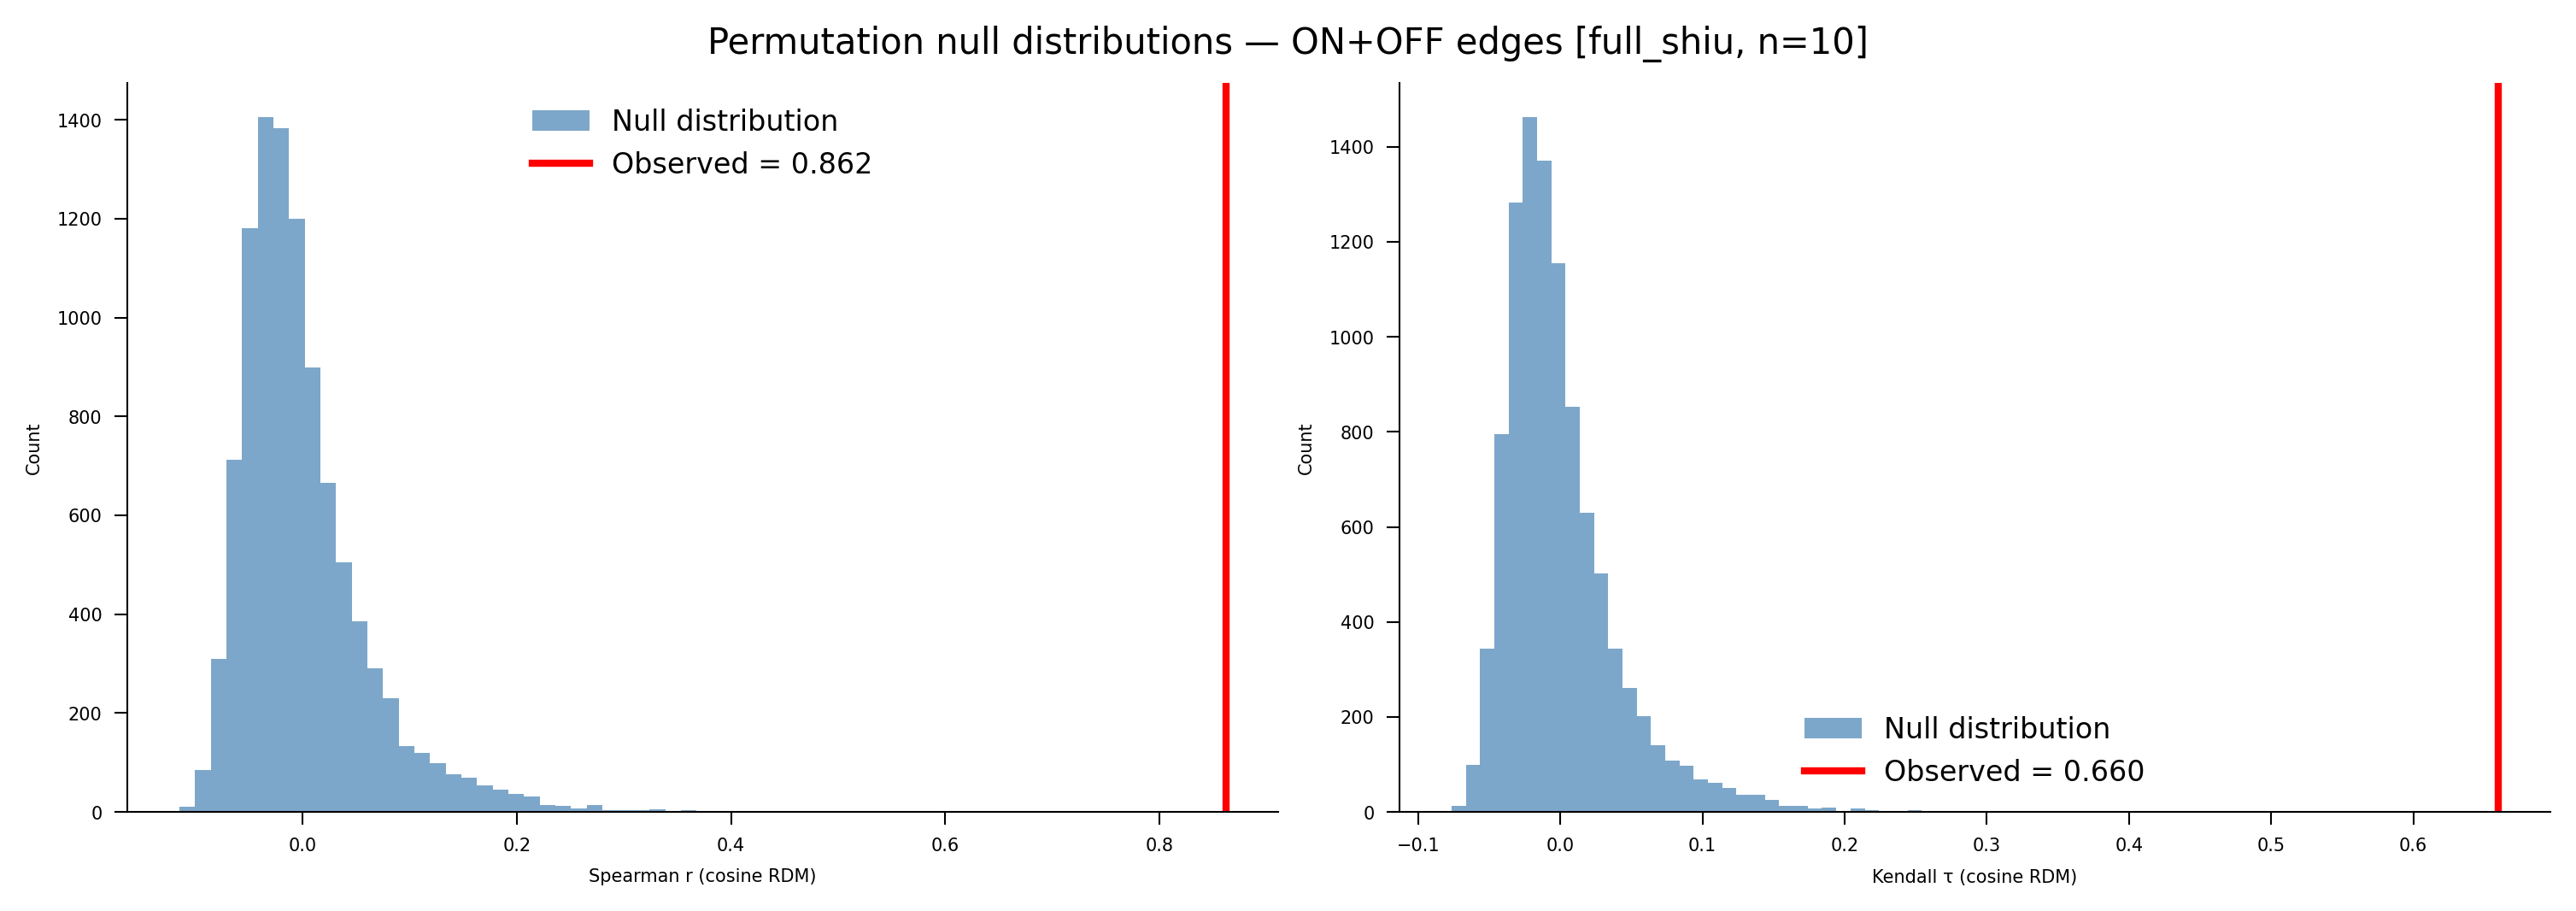


  Interpretation:
  Low r  → CC and random networks have DIFFERENT representational geometry
  High r → similar geometry (random network could substitute connectome)

--- WITHIN-ENSEMBLE RDM CONSISTENCY (CC models) ---
  Mean pairwise RDM correlation across CC models: 0.850 ± 0.057

--- GENERATING FIGURE ---
  Saved: moving_edge_on_off_rdms_10models_full_shiu.png


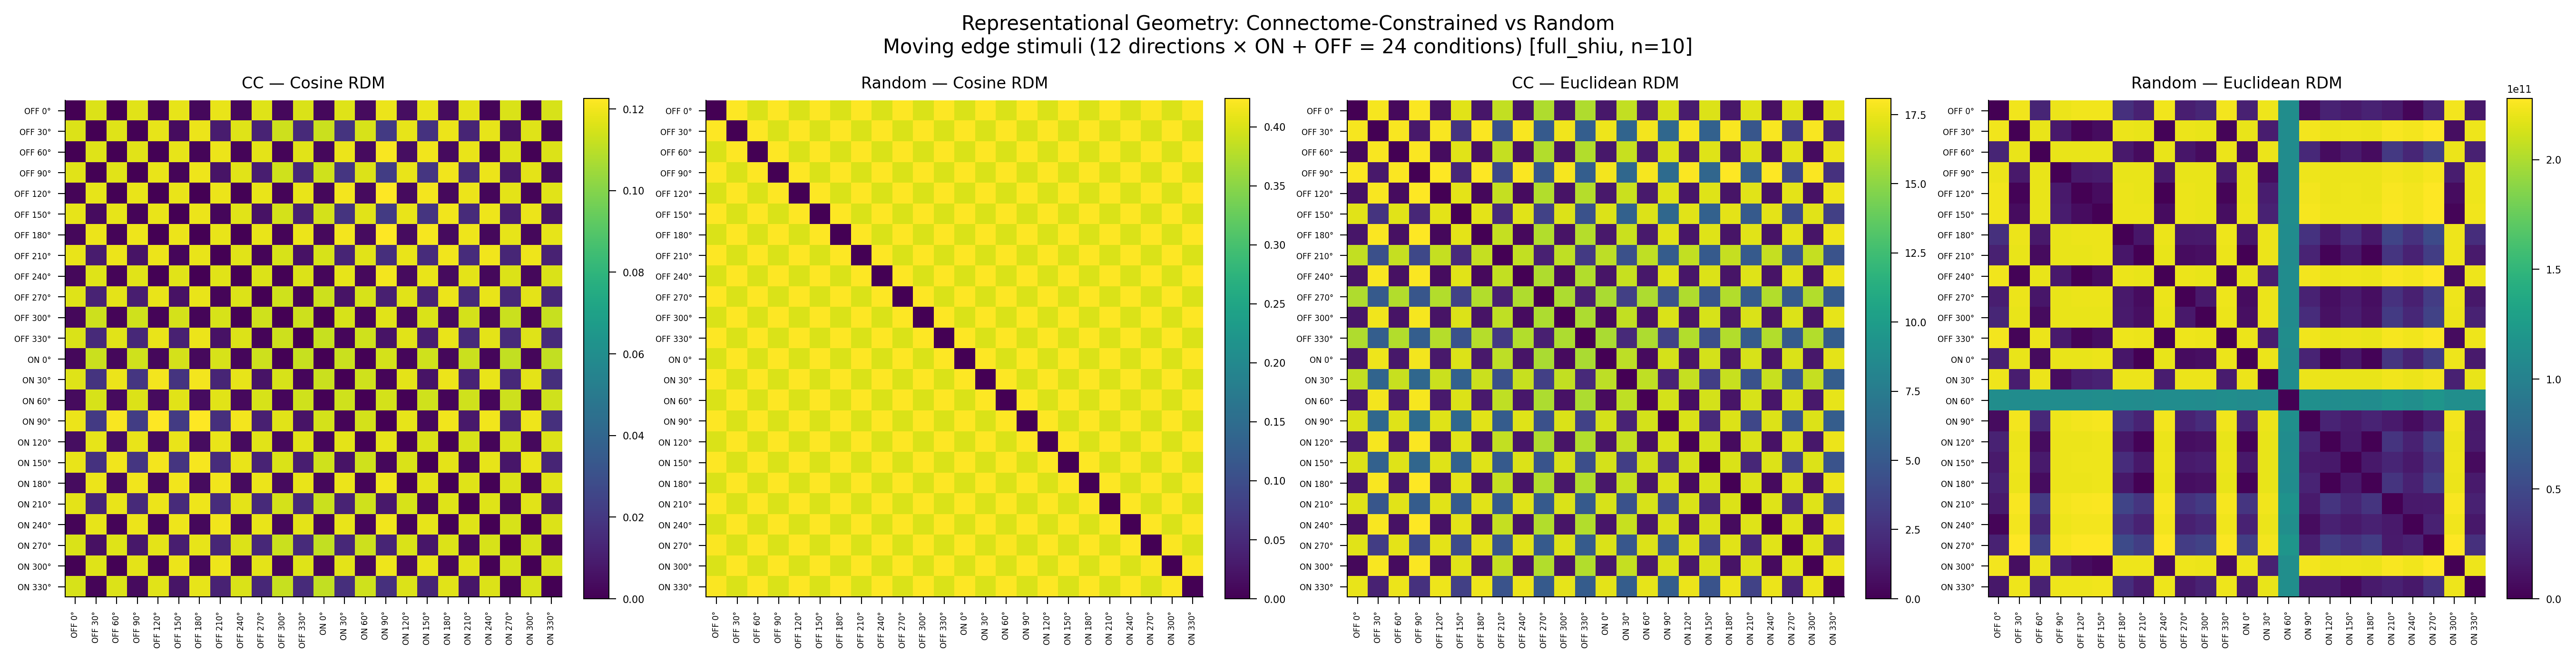


SUMMARY
  N stimuli:              24 (ON + OFF edges, 12 directions each)
  N models:               10
  Randomization strategy: full_shiu
  Population vec dim:     65 (cell types)
  Cosine RDM corr (CC vs random):    Spearman r = 0.862 | Kendall τ = 0.660  [analytical]
                                     Spearman r = 0.862, p_perm = 0.0000 | Kendall τ = 0.660, p_perm = 0.0000  [permutation]
  Euclidean RDM corr (CC vs random): Spearman r = 0.051 | Kendall τ = 0.034  [analytical]
  Within-CC consistency:             r = 0.850 ± 0.057


{'cc_rdm_cosine': array([[0.        , 0.1162156 , 0.00038589, 0.11699746, 0.00159581,
         0.1181784 , 0.00278876, 0.11865982, 0.00258232, 0.11678474,
         0.00240921, 0.11545726, 0.0025367 , 0.1165615 , 0.00382014,
         0.11894372, 0.00471418, 0.11841077, 0.00394019, 0.11764759,
         0.00178642, 0.11552564, 0.00048132, 0.11504465],
        [0.1162156 , 0.        , 0.1167566 , 0.00076272, 0.11818342,
         0.00390109, 0.11909328, 0.00933269, 0.11656408, 0.01211477,
         0.11325092, 0.01463336, 0.1125989 , 0.01853461, 0.11531892,
         0.02076964, 0.11803755, 0.01777225, 0.1190002 , 0.01260695,
         0.11781806, 0.00569689, 0.11661573, 0.00149767],
        [0.00038589, 0.1167566 , 0.        , 0.11725906, 0.00060431,
         0.11804982, 0.00161452, 0.1187833 , 0.00158242, 0.11767066,
         0.00185266, 0.11716255, 0.00250235, 0.11890277, 0.00382831,
         0.12118829, 0.00436917, 0.11988266, 0.0036418 , 0.11864736,
         0.00179688, 0.11651323, 0.0007

In [3]:
results = run_experiment(n_models=10, randomization_strategy="full_shiu")
results

## Results

### CC Cosine RDM
The connectome-constrained network produces a structured 24×24 dissimilarity matrix with clear polarity-dependent block organization. Within each polarity block (ON-ON and OFF-OFF), the same circular direction gradient observed in Experiment 1 is preserved: adjacent directions are most similar and opposite directions most dissimilar. Across polarity (ON vs OFF pairs), dissimilarities are large and nearly uniform at ~0.099–0.103 — the network represents ON and OFF edges as geometrically distinct populations regardless of direction. This block structure is consistent with the known segregation of the fly visual system into ON (T4) and OFF (T5) pathways.

### Random Cosine RDM
Under the full Shiu-style shuffle at n=10 (5/10 stable random models), the random baseline produces a 24×24 matrix with values alternating between ~0.400 (within-polarity pairs) and ~0.423 (cross-polarity pairs). The polarity block structure is present but the within-polarity direction gradient is absent — the random network encodes polarity identity but cannot resolve directional structure. Under the synapse-only shuffle at n=50 (35/50 unstable), the mean random cosine RDM collapses to NaN due to numerical overflow.

### Dynamic Instability
Under the full Shiu-style shuffle at n=10, 5 of 10 random models were unstable (1,512 non-finite values each, corresponding to 63 of 65 cell types across all 24 stimuli) — identical model indices as Experiment 1 (models 2, 3, 4, 8, 9), confirming that the instability pattern is reproducible under seed=42 regardless of stimulus count. Under the synapse-only shuffle at n=50, 35 of 50 random models (70%) were unstable — comparable to the Experiment 1 synapse-only rate (34/50, 68%). One model in the n=50 run produced 378 non-finite values — partial instability affecting a subset of stimuli rather than full collapse. 0 of 50 CC models showed any instability under any condition.

### CC vs Random RDM Correlation
Under the full Shiu-style shuffle at n=10 with 5/10 stable random models, cosine RDM correlation: **Spearman r = 0.862, p < 0.0001 | Kendall τ = 0.660, p < 0.0001** (analytical); **p_perm < 0.0001 for both measures** (stimulus-label randomization test, 10,000 permutations, Nili et al. 2014) — zero of 10,000 permutations exceeded the observed correlation. This result is highly significant by all inference methods, stronger than the Experiment 1 result (r = 0.757, τ = 0.562), and consistent with the richer constraint provided by 24 stimulus conditions. It confirms that representational geometry is a fidelity-discriminating signal that generalizes across polarity, not just direction.

Under the synapse-only shuffle at n=50, cosine RDM correlation: **r = NaN** — not computable due to numerical overflow.

Euclidean RDM correlation: **Spearman r = 0.051, p = 0.400 | Kendall τ = 0.034, p = 0.398** (analytical); **p_perm = 0.164 | p_perm = 0.163** (permutation) — not significant by either inference method (full Shiu-style shuffle, n=10); **Spearman r = 0.313, p < 0.0001 | Kendall τ = 0.229, p < 0.0001** (synapse-only shuffle, n=50) — nominally significant but not scientifically interpretable, as the mean random Euclidean RDM is dominated by extreme magnitudes (~10²–10¹¹) from unstable models whose exploding activations create structured variance that incidentally correlates with the CC pattern. This is a numerical artifact, not a fidelity signal.

**Interpretive note**: The cosine RDM correlation result is significant by analytical p-values, Kendall τ, and permutation test — three independent inference methods converging on the same conclusion, consistent with Experiment 1. The Euclidean result is non-significant by all methods including permutation, providing clean confirmation that it carries no fidelity signal under these conditions.

### Within-Ensemble Consistency
At n=10, mean pairwise RDM correlation: **r = 0.850 ± 0.057**. At n=50, mean pairwise RDM correlation: **r = 0.838 ± 0.059**. Both are notably higher and tighter than the n=50 ON-only result (r = 0.721 ± 0.150), suggesting that the ON+OFF stimulus set produces a more consistent representational geometry — likely because 24 conditions provide a richer constraint on the population code than 12. The n=10 ON+OFF result (r = 0.850) also slightly exceeds the n=10 ON-only result (r = 0.838 ± 0.078), consistent with polarity being a stronger organizer of representational geometry than direction alone.

## Discussion
- Across both experiments, the cosine RDM correlation is significant by analytical p-values, Kendall τ, and permutation test — three independent inference methods converging on the same conclusion (Experiment 1: r = 0.757, τ = 0.562; Experiment 2: r = 0.862, τ = 0.660; p_perm < 0.0001 in both cases)
- The Euclidean result is non-significant by all methods including permutation in both experiments, confirming cosine distance as the appropriate primary metric
- The within-ensemble consistency improvement from ON-only (r = 0.721 at n=50) to ON+OFF (r = 0.838 at n=50, r = 0.850 at n=10) supports polarity as a stronger organizer of representational geometry than direction alone
- Dynamic instability pattern is fully reproducible across both experiments under seed=42 with the full Shiu-style shuffle

## Download Figure

In [5]:
# Download figure to local machine
from google.colab import files
files.download("moving_edge_on_off_rdms_10models_full_shiu.png")
files.download("moving_edge_on_off_permtest_10models_full_shiu.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>